Ryanair DS - Fabrizio Bernardi

**To run:** Update the path of `interview_data_deliverable.csv` and `interview_data_deliverable_second_part.csv`based on their position on your local machine,
then run all cells top to bottom (Kernel → Restart & Run All). Add missing libraries with 
_!pip install library_name_ if needed

**To save results**  Enable saving in the save option cell and specify a path for the pickle




In [3]:
# Dataset paths

dataset1 = r"C:\Users\Fabrizio\Downloads\ds-test-main\ds-test-main\Test\interview_data_deliverable.csv"

dataset2 = r"C:\Users\Fabrizio\Downloads\ds-test-main\ds-test-main\Test\interview_data_deliverable_second_part.csv"

In [4]:
# save options

save_clustering_model = 1 # 1 to save
save_prediction_model = 1 # 1 to save

output_path = r"C:\Users\Fabrizio\Downloads\ds-test-main\ds-test-main\output" # path where to save your models


# Part 0: load dataset and QC

In [109]:
# Core Python / data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test splitting
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Imputation
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats
from scipy.stats import mannwhitneyu
import numpy as np
from scipy.stats import rankdata
from sklearn.cluster import AgglomerativeClustering

from pathlib import Path
import pickle


In [7]:
df = pd.read_csv(dataset1)

In [8]:
df.head()

,dep_date,model,inv_leg_id,booking_ts,passenger_id,fare_eur,is_active
0,2024-06-01,B,1032113828,2024-05-14 14:36:19.427000 UTC,246249517162,17.32,True
1,2024-06-01,B,1032113828,2024-05-27 20:08:31.823000 UTC,247359065477,68.18,True
2,2024-06-01,B,1032113828,2024-05-17 15:52:11.560000 UTC,246532425826,21.96,True
3,2024-06-01,B,1032113828,2024-05-19 17:55:50.427000 UTC,246678267820,18.49,True
4,2024-06-01,B,1032113828,2024-04-21 08:16:07.213000 UTC,244268267749,20.28,True


In [9]:
df.dtypes

dep_date         object
model            object
inv_leg_id        int64
booking_ts       object
passenger_id      int64
fare_eur        float64
is_active          bool
dtype: object

In [10]:
# No missing values
df.isna().sum()

dep_date        0
model           0
inv_leg_id      0
booking_ts      0
passenger_id    0
fare_eur        0
is_active       0
dtype: int64

In [11]:
df.shape

(1472611, 7)

In [12]:
len(df) - len(df.drop_duplicates()) # 32 full row duplicates, let's drop them

32

In [13]:
df = df.drop_duplicates().reset_index(drop=True)
print(len(df))
print(len(df) - len(df.drop_duplicates()))

1472579
0


In [14]:
df.nunique()

dep_date             92
model                 2
inv_leg_id        13777
booking_ts       871065
passenger_id    1270808
fare_eur          28641
is_active             2
dtype: int64

In [15]:
n_unique = df.drop_duplicates(subset=["inv_leg_id", "passenger_id"]).shape[0]
n_unique

1472443

In [16]:
1472579 - 1472443

136

In [17]:
# (Passenger id, flight id) is not a unique identifier as I would have expected, let's explore that more

In [18]:
viol = df[df.duplicated(subset=["inv_leg_id", "passenger_id"], keep=False)]
viol

,dep_date,model,inv_leg_id,booking_ts,passenger_id,fare_eur,is_active
5953,2024-06-02,B,1032250419,2024-05-31 21:59:12.783000 UTC,247714693646,17.64,False
5974,2024-06-02,B,1032250419,2024-05-31 21:59:12.783000 UTC,247714693646,36.66,True
10384,2024-06-03,B,1032362520,2024-05-24 09:52:39.733000 UTC,247083992034,30.04,False
10442,2024-06-03,B,1032362520,2024-05-24 09:52:39.733000 UTC,247083992034,30.04,True
47918,2024-06-10,A,1033236971,2024-04-01 17:34:56.470000 UTC,242660482021,31.87,True
...,...,...,...,...,...,...,...
1391812,2024-08-18,A,1100495359,2024-07-27 22:21:04.767000 UTC,251800259501,345.18,False
1414697,2024-07-17,B,1101650260,2024-05-22 15:22:18.540000 UTC,246935664586,99.38,False
1414702,2024-07-17,B,1101650260,2024-05-22 15:22:18.540000 UTC,246935664586,99.38,True
1452155,2024-06-17,A,1102551018,2024-05-17 00:06:41.233000 UTC,246482975366,57.56,False


In [19]:
viol = df[df.duplicated(subset=["inv_leg_id", "passenger_id","fare_eur","is_active"], keep=False)]
len(viol)

0

In [20]:
viol2 = df[df.duplicated(subset=["inv_leg_id", "passenger_id","booking_ts"], keep=False)]
len(viol2)

272

In [21]:
# 272 rows with strange behaviour, booking at same time for same flight and passenger,
# but appearing with different values of amount and/or is_active
# What I would do in a real situation: report this to the owner of the dataset and discuss the origin of the issue and the fix.

# In the following I won't delete such duplicates, accepting that each contributes independently
# to flight-level aggregates

In [22]:
# booking must be always before departure
df["dep_date"] = pd.to_datetime(df["dep_date"], format="%Y-%m-%d")
df["booking_ts"] = pd.to_datetime(df["booking_ts"], format="%Y-%m-%d %H:%M:%S.%f %Z", utc=True)
df["booking_ts"] = df["booking_ts"].dt.tz_localize(None)
(df["dep_date"].dt.date < df["booking_ts"].dt.date).sum()

5

In [23]:
df[df["dep_date"].dt.date < df["booking_ts"].dt.date] # These rows have departure date before booking date, always 1 cent

,dep_date,model,inv_leg_id,booking_ts,passenger_id,fare_eur,is_active
901636,2024-07-24,A,1059464260,2024-07-25 03:47:29.327,251611578841,0.01,False
901656,2024-07-24,A,1059464260,2024-07-25 03:47:29.327,251611578648,0.01,False
901689,2024-07-24,A,1059464260,2024-07-25 03:47:29.327,251611579034,0.01,False
901721,2024-07-24,A,1059464260,2024-07-25 03:47:29.327,251611578455,0.01,False
1295726,2024-07-27,B,1083259771,2024-07-28 05:11:48.920,251803814175,0.01,False


In [24]:
# I would report this finding (even if quite negligible). For now I will drop these rows and evaluate them as artifact

In [25]:
df = df[df["dep_date"].dt.date >= df["booking_ts"].dt.date]
len(df)

1472574

In [26]:
# unique flight should have unique departure date and pricing model

df_check = df.groupby("inv_leg_id").agg(
    n_dep_dates=("dep_date", "nunique"),
    n_models=("model", "nunique"),
)
print("Flights with >1 dep_date:", (df_check["n_dep_dates"] > 1).sum())
print("Flights with >1 model:", (df_check["n_models"] > 1).sum())

Flights with >1 dep_date: 0
Flights with >1 model: 0


count    1.472574e+06
mean     8.220191e+01
std      7.337727e+01
min     -1.761000e+01
25%      3.036000e+01
50%      5.574000e+01
75%      1.088700e+02
max      5.900700e+02
Name: fare_eur, dtype: float64
Zero or negative fares: 50


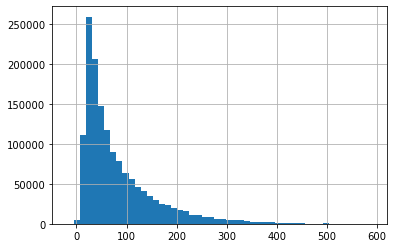

In [27]:
# negative values should be acceptable (refunds), would just double check that with the team
df["fare_eur"].hist(bins=50)

print(df["fare_eur"].describe())
print("Zero or negative fares:", (df["fare_eur"] <= 0).sum()) # skewed distribution to the right side

count    13777.000000
mean       106.886405
std         21.700891
min          1.000000
25%         98.000000
50%        111.000000
75%        122.000000
max        176.000000
dtype: float64


<AxesSubplot:>

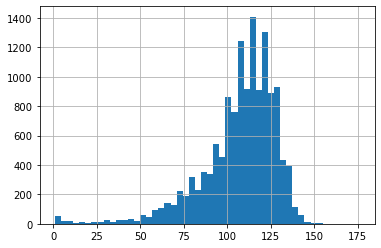

In [28]:

bookings_per_flight = df.groupby("inv_leg_id").size()
print(bookings_per_flight.describe())

bookings_per_flight.hist(bins=50)

In [29]:
df["dep_date"].describe() # we have 3 months of data

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_23684\2201139301.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df["dep_date"].describe() # we have 3 months of data


count                 1472574
unique                     92
top       2024-08-16 00:00:00
freq                    18673
first     2024-06-01 00:00:00
last      2024-08-31 00:00:00
Name: dep_date, dtype: object

# Part 1: Flight clustering

In [30]:
# The dataset is not at flight level. In order to build flight clusters, let's first aggregate main features to create a
# flight level dataset

flight_df = df.groupby("inv_leg_id").agg(
    n_bookings=("passenger_id", "count"),
    n_active=("is_active", "sum"),
    fare_mean=("fare_eur", "mean"),
    fare_median=("fare_eur", "median"), # I consider it as well since I saw skeweness in the distribution
    dep_date=("dep_date", "first")
).reset_index()
flight_df

,inv_leg_id,n_bookings,n_active,fare_mean,fare_median,dep_date
0,1032113828,104,100,31.351058,22.975,2024-06-01
1,1032113907,103,103,41.231165,38.590,2024-06-01
2,1032115566,111,107,43.324775,34.960,2024-06-01
3,1032115645,111,110,60.981351,41.400,2024-06-01
4,1032117067,113,113,45.763363,37.850,2024-06-01
...,...,...,...,...,...,...
13772,1105004284,116,113,22.457241,18.580,2024-07-12
13773,1105004363,92,91,21.794022,17.680,2024-07-19
13774,1105004600,139,139,55.416906,48.370,2024-08-09
13775,1105004679,135,128,96.031333,85.100,2024-08-16


Now let's add new relevant features:
- the month of the flight: I might expect different behaviors for different months (like summer ones)
- the type of day of the fligh (weekend or not weekend), for same reasons
- the rate of non activity (i.e cancellation rate)



In [31]:
flight_df["cancel_rate"] = 1 - flight_df["n_active"] / flight_df["n_bookings"]
flight_df["weekend"] = flight_df["dep_date"].dt.dayofweek.isin([5, 6]).astype(int)
flight_df["month"] = flight_df["dep_date"].dt.month
flight_df

,inv_leg_id,n_bookings,n_active,fare_mean,fare_median,dep_date,cancel_rate,weekend,month
0,1032113828,104,100,31.351058,22.975,2024-06-01,0.038462,1,6
1,1032113907,103,103,41.231165,38.590,2024-06-01,0.000000,1,6
2,1032115566,111,107,43.324775,34.960,2024-06-01,0.036036,1,6
3,1032115645,111,110,60.981351,41.400,2024-06-01,0.009009,1,6
4,1032117067,113,113,45.763363,37.850,2024-06-01,0.000000,1,6
...,...,...,...,...,...,...,...,...,...
13772,1105004284,116,113,22.457241,18.580,2024-07-12,0.025862,0,7
13773,1105004363,92,91,21.794022,17.680,2024-07-19,0.010870,0,7
13774,1105004600,139,139,55.416906,48.370,2024-08-09,0.000000,0,8
13775,1105004679,135,128,96.031333,85.100,2024-08-16,0.051852,0,8


In [32]:
print(flight_df.weekend.unique())
print(flight_df.month.unique()) # we are actually in same season but maybe we can still see some differences

[1 0]
[6 7 8]


In [33]:
flight_df.columns

Index(['inv_leg_id', 'n_bookings', 'n_active', 'fare_mean', 'fare_median',
       'dep_date', 'cancel_rate', 'weekend', 'month'],
      dtype='object')

In [34]:
flight_df.groupby('weekend')['fare_median'].mean() # as expected higher prices on weekend

weekend
0    73.398645
1    82.052590
Name: fare_median, dtype: float64

In [35]:
clustering_features = [
    'n_bookings', 'n_active', 'fare_mean', 'fare_median', 'cancel_rate', 'weekend', 'month'
] # all except of date, too granular

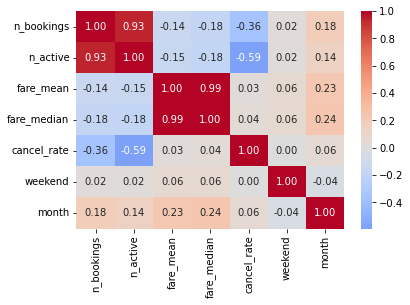

In [36]:

sns.heatmap(flight_df[clustering_features].corr()
, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

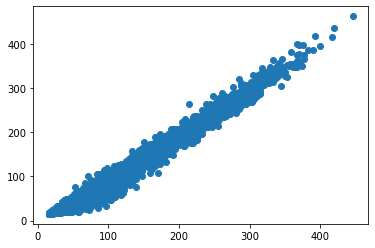

In [37]:
plt.plot(flight_df['fare_mean'], flight_df['fare_median'], 'o')
plt.show()

In [38]:
# Issue with month: in algorithms distanced based like k-means, I would incorrectly consider
# distant months which are between consecutive year
# This is not a problem for this particular case since we have 3 months only, but for a general case I need to take into account.
# one hot encoding could solve this but with 12 months could increase feature dimension too much.
# I would first group into 4 seasons and then create dummy variables


<AxesSubplot:>

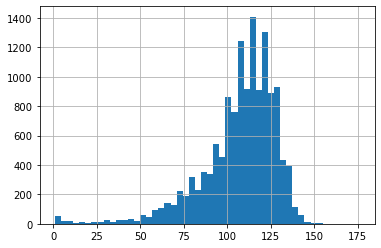

In [39]:
flight_df.n_bookings.hist(bins=50)

In [40]:
flight_df.n_bookings.describe()

count    13777.000000
mean       106.886405
std         21.700891
min          1.000000
25%         98.000000
50%        111.000000
75%        122.000000
max        176.000000
Name: n_bookings, dtype: float64

In [41]:
clustering_features = [
    'n_bookings', 'fare_mean', 'cancel_rate', 'weekend', 'month'
] # Let's keep median only

In [42]:
X = flight_df[clustering_features].copy()
X['fare_mean'] = np.log1p(X['fare_mean']) # scaling for skeweness
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [43]:
X_scaled

,n_bookings,fare_mean,cancel_rate,weekend,month
0,-0.133013,-1.070287,0.000196,1.560935,-1.247673
1,-0.179096,-0.678920,-0.298110,1.560935,-1.247673
2,0.189566,-0.607868,-0.018616,1.560935,-1.247673
3,0.189566,-0.115502,-0.228236,1.560935,-1.247673
4,0.281731,-0.529221,-0.298110,1.560935,-1.247673
...,...,...,...,...,...
13772,0.419979,-1.542355,-0.097525,-0.640642,-0.020487
13773,-0.686006,-1.584473,-0.213806,-0.640642,-0.020487
13774,1.479882,-0.253634,-0.298110,-0.640642,1.206699
13775,1.295551,0.542671,0.104051,-0.640642,1.206699


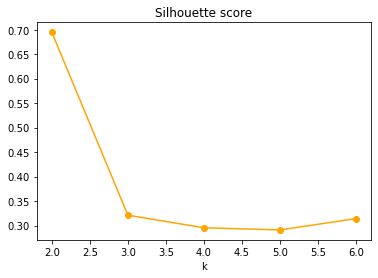

In [44]:
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))



plt.plot(list(K_range), sil_scores, marker='o', color='orange')
plt.title('Silhouette score')
plt.xlabel('k')
plt.show()

# Except for k=2 (too simple case), silhouette is quite similar between k, slightly higher for k=6

In [45]:
# 2 Clusters are just dividing between cancellations and non

km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_scaled)
flight_df['cluster_2'] = km2.fit_predict(X_scaled)
print(flight_df.groupby('cluster_2')[clustering_features].mean())

           n_bookings  fare_mean  cancel_rate   weekend     month
cluster_2                                                        
0          107.979014  84.207466     0.021494  0.290845  7.011897
1           46.286885  76.115931     0.978098  0.299180  7.282787


In [46]:
flight_all_inactive = df.groupby("inv_leg_id")["is_active"].agg(lambda x: (~x).all())
fully_inactive_ids = set(flight_all_inactive[flight_all_inactive].index)

# Flights assigned to cluster 1 (the ~97.5% cancel rate cluster)
cluster1_ids = set(flight_df.loc[flight_df['cluster_2'] == 1, 'inv_leg_id'])

# Overlap
overlap = fully_inactive_ids & cluster1_ids
len(overlap)

155

In [47]:
flight_df['cluster_2'].value_counts()

0    13533
1      244
Name: cluster_2, dtype: int64

In [48]:
# Cluster 1 is mostly cluster of cancelled flights or in which most of the passengers cancelled
155/244

0.6352459016393442

In [49]:
km6 = KMeans(n_clusters=6, n_init=10, random_state=999).fit(X_scaled)
flight_df['cluster_6'] = km6.fit_predict(X_scaled)
print(flight_df.groupby('cluster_6')[clustering_features].mean())

           n_bookings   fare_mean  cancel_rate  weekend     month
cluster_6                                                        
0          112.489188  113.596713     0.024068  1.00000  7.624700
1           98.998254   52.759793     0.018203  0.00000  6.176950
2          104.778078   63.805341     0.017916  1.00000  6.209503
3           46.286885   76.115931     0.978098  0.29918  7.282787
4          102.204443  160.897981     0.028001  0.00113  7.468373
5          120.161916   50.282126     0.020154  0.00000  7.544185


In [50]:
flight_df['cluster_6'].value_counts()

5    3508
1    3436
4    2656
0    2081
2    1852
3     244
Name: cluster_6, dtype: int64

Cluster 0 – Weekend, Higher Fare (Peak Summer): Weekend departures in late July combining seasonal and weekend effects

Cluster 1 – Weekday, Low Fare (Early Summer): Weekday departures in June with low average fares and standard booking volume and cancellation behavior.

Cluster 2 – Weekend, Mid Fare (Early Summer): Weekend departures in June with moderately higher fares than weekday equivalents, standard volume and cancellations.

Cluster 3 – Canceled / Disrupted Flights: Flights with a near-total cancellation rate

Cluster 4 – Premium Fare Segment: Weekday flights with a distinctly higher average fare, despite normal booking volume and cancellation rate. 

Cluster 5 – Weekday, Low Fare (Peak Summer): Weekday departures in late July with the highest booking volume  and low fares, standard cancellation rate.



In [48]:


agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

flight_df['cluster_hier'] = agg_labels

# Agreement between K-Means and Hierarchical
ari = adjusted_rand_score(flight_df['cluster_6'], flight_df['cluster_hier'])
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}")

print(f"Hierarchical silhouette: {silhouette_score(X_scaled, agg_labels):.3f}")
print(f"K-Means silhouette:      {silhouette_score(X_scaled, flight_df['cluster_6']):.3f}")

Adjusted Rand Index (K-Means vs Hierarchical): 0.773
Hierarchical silhouette: 0.295
K-Means silhouette:      0.314


In [67]:
# Build single pipeline to be saved

if save_clustering_model:
    pipeline_clustering = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=6, n_init=10, random_state=999))
    ])
    
    pipeline_clustering.fit(X)
    
    output_file = Path(output_path) / "kmeans_pipeline.pkl"
    
    with open(output_file, "wb") as f:
        pickle.dump(pipeline_clustering, f)
    
    print(f"Pipeline saved to: {output_file}")

Pipeline saved to: C:\Users\Fabrizio\Downloads\ds-test-main\ds-test-main\output\kmeans_pipeline.pkl


XX = X.copy()

with open(output_file, "rb") as f:
    pipeline = pickle.load(f)
    
XX['clusters'] = pipeline.predict(X)
XX['clusters'].value_counts()

# Part 2: Pricing model evaluation

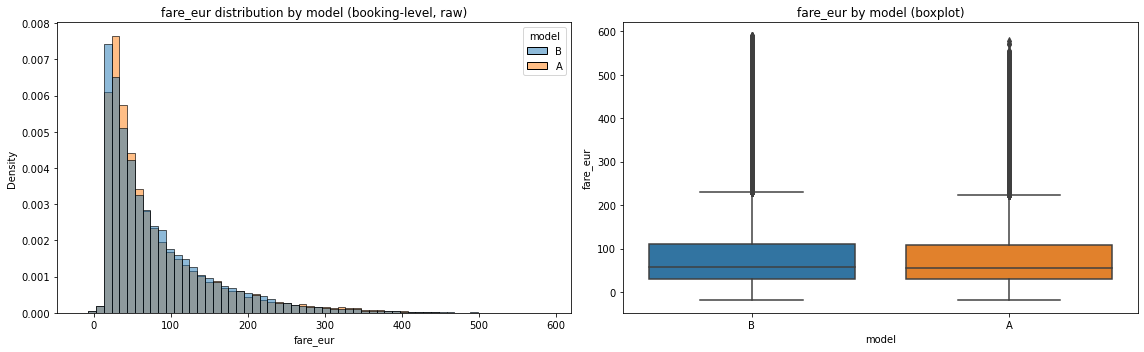

          count       mean        std    min    25%    50%     75%     max
model                                                                     
A      734397.0  82.105850  74.125146 -17.61  30.85  54.67  107.56  577.71
B      738177.0  82.297478  72.625511 -17.35  30.04  56.78  110.19  590.07


In [51]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df, x='fare_eur', hue='model', stat='density',bins=60, ax=axes[0])
axes[0].set_title('fare_eur distribution by model (booking-level, raw)')
axes[0].set_xlabel('fare_eur')

sns.boxplot(data=df, x='model', y='fare_eur', ax=axes[1])
axes[1].set_title('fare_eur by model (boxplot)')

plt.tight_layout()
plt.show()

print(df.groupby('model')['fare_eur'].describe())

In [51]:
df.groupby('model')['is_active'].mean() # No particular differences in cancellations

model
A    0.970809
B    0.971195
Name: is_active, dtype: float64

In [52]:
len(df)

1472574

In [54]:
# Pricing should consider only active flights

revenue = (
    df[df['is_active']]
    .groupby('inv_leg_id')['fare_eur']
    .agg(revenue_total='sum', revenue_mean='mean')
    .reset_index()
)

In [55]:
revenue

,inv_leg_id,revenue_total,revenue_mean
0,1032113828,3077.21,30.772100
1,1032113907,4246.81,41.231165
2,1032115566,4678.25,43.721963
3,1032115645,6728.69,61.169909
4,1032117067,5171.26,45.763363
...,...,...,...
13617,1105004284,2522.19,22.320265
13618,1105004363,1979.34,21.750989
13619,1105004600,7702.95,55.416906
13620,1105004679,12254.39,95.737422


In [56]:
df.groupby('inv_leg_id')['model'].nunique().max() # 1 pricing per flight

1

In [79]:
df.groupby('model')['is_active'].sum() / df.groupby('model')['inv_leg_id'].count()

model
A    0.970809
B    0.971195
dtype: float64

In [81]:
flight_level.groupby('model')['n_active'].sum()

model
A    712959
B    716914
Name: n_active, dtype: int64

In [69]:
flight_level = df.groupby(['inv_leg_id', 'model']).agg(
    n_bookings=('passenger_id', 'count'),
    n_active=('is_active', 'sum'),
    fare_mean=('fare_eur', 'mean'),
    fare_std=('fare_eur', 'std'),
).reset_index()

flight_level = flight_level.merge(revenue, on='inv_leg_id', how='left')

flight_level['cancel_rate'] = 1 - flight_level['n_active'] / flight_level['n_bookings']

In [70]:
flight_level

,inv_leg_id,model,n_bookings,n_active,fare_mean,fare_std,revenue_total,revenue_mean,cancel_rate
0,1032113828,B,104,100,31.351058,18.855037,3077.21,30.772100,0.038462
1,1032113907,A,103,103,41.231165,13.449102,4246.81,41.231165,0.000000
2,1032115566,A,111,107,43.324775,23.178477,4678.25,43.721963,0.036036
3,1032115645,A,111,110,60.981351,37.785112,6728.69,61.169909,0.009009
4,1032117067,B,113,113,45.763363,24.177854,5171.26,45.763363,0.000000
...,...,...,...,...,...,...,...,...,...
13772,1105004284,B,116,113,22.457241,12.131125,2522.19,22.320265,0.025862
13773,1105004363,B,92,91,21.794022,7.351929,1979.34,21.750989,0.010870
13774,1105004600,A,139,139,55.416906,37.212354,7702.95,55.416906,0.000000
13775,1105004679,B,135,128,96.031333,35.651400,12254.39,95.737422,0.051852


In [71]:
flight_level.isna().sum()

inv_leg_id         0
model              0
n_bookings         0
n_active           0
fare_mean          0
fare_std          28
revenue_total    155
revenue_mean     155
cancel_rate        0
dtype: int64

In [73]:
metrics = ['n_bookings', 'cancel_rate', 'fare_mean', 'revenue_mean']
summary = flight_level.groupby('model')[metrics].agg(['mean', 'median', 'std', 'count'])
print(summary)

       n_bookings                         cancel_rate                      \
             mean median        std count        mean    median       std   
model                                                                       
A      107.054956  111.0  22.341562  6860    0.040012  0.016129  0.134878   
B      106.719242  111.0  21.046530  6917    0.036873  0.016393  0.122753   

             fare_mean                             revenue_mean             \
      count       mean     median        std count         mean     median   
model                                                                        
A      6860  84.162081  62.844684  63.820732  6860    84.362529  63.018051   
B      6917  83.967044  63.713905  63.147786  6917    84.011309  63.616612   

                        
             std count  
model                   
A      64.162764  6771  
B      63.338067  6851  


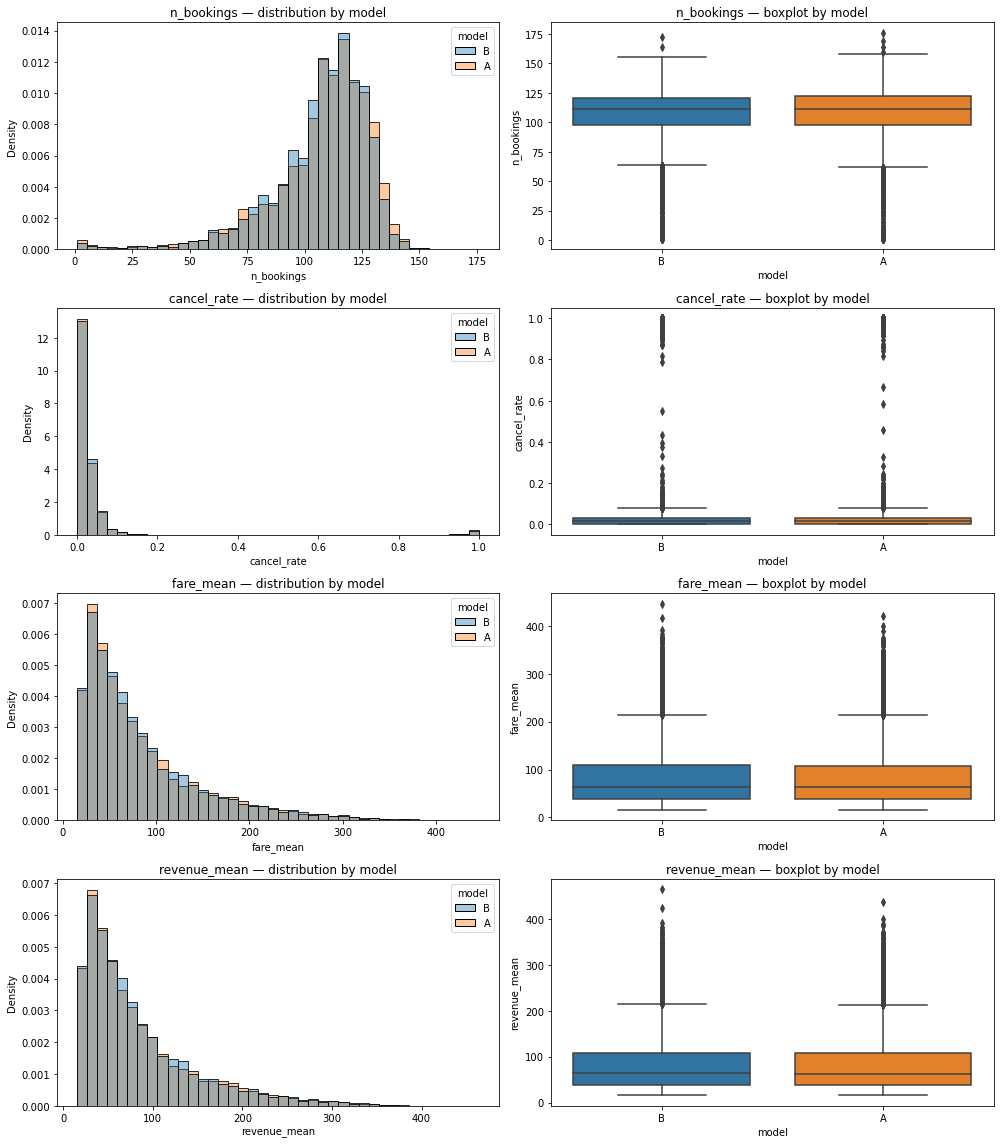

In [83]:



fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4*len(metrics)))

for i, m in enumerate(metrics):
    sns.histplot(data=flight_level, x=m, hue='model', stat='density', alpha=0.4, bins=40, ax=axes[i,0])
    axes[i,0].set_title(f'{m} — distribution by model')

    # Right: boxplot, good for spotting median/IQR/outlier differences at a glance
    sns.boxplot(data=flight_level, x='model', y=m, ax=axes[i,1])
    axes[i,1].set_title(f'{m} — boxplot by model')

plt.tight_layout()
plt.show()

In [84]:

metrics = ['n_bookings', 'cancel_rate', 'fare_mean', 'revenue_mean']

a = flight_level[flight_level['model'] == 'A']
b = flight_level[flight_level['model'] == 'B']

for m in metrics:
    for grp, label in [(a, 'A'), (b, 'B')]:
        data = grp[m].dropna()
       
        stat, p = stats.normaltest(data)
        test_name = "D'Agostino-Pearson"

        verdict = "normal" if p > 0.05 else "NOT normal"
        print(f"{m} — Model {label}: {test_name}, stat={stat:.2f}, p={p:.6f} "
              f"({verdict}), n={len(data)}, skew={data.skew():.2f}")
    print()

n_bookings — Model A: D'Agostino-Pearson, stat=2128.69, p=0.000000 (NOT normal), n=6860, skew=-1.57
n_bookings — Model B: D'Agostino-Pearson, stat=2050.49, p=0.000000 (NOT normal), n=6917, skew=-1.50

cancel_rate — Model A: D'Agostino-Pearson, stat=8166.70, p=0.000000 (NOT normal), n=6860, skew=6.63
cancel_rate — Model B: D'Agostino-Pearson, stat=8733.51, p=0.000000 (NOT normal), n=6917, skew=7.24

fare_mean — Model A: D'Agostino-Pearson, stat=1940.20, p=0.000000 (NOT normal), n=6860, skew=1.59
fare_mean — Model B: D'Agostino-Pearson, stat=2071.96, p=0.000000 (NOT normal), n=6917, skew=1.63

revenue_mean — Model A: D'Agostino-Pearson, stat=1930.32, p=0.000000 (NOT normal), n=6771, skew=1.60
revenue_mean — Model B: D'Agostino-Pearson, stat=2063.50, p=0.000000 (NOT normal), n=6851, skew=1.64



In [85]:


def cliffs_delta_fast(x, y):
    n_x, n_y = len(x), len(y)
    all_data = np.concatenate([x, y])
    ranks = rankdata(all_data)
    rank_sum_x = ranks[:n_x].sum()
    auc = (rank_sum_x - n_x*(n_x+1)/2) / (n_x * n_y)
    return 2*auc - 1

for m in ['n_bookings', 'cancel_rate', 'fare_mean_all' if 'fare_mean_all' in flight_level.columns else 'fare_mean', 'revenue_mean']:
    stat, p = mannwhitneyu(a[m].dropna(), b[m].dropna())
    d = cliffs_delta_fast(a[m].dropna(), b[m].dropna())
    print(f"{m}: p={p:.4f}, Cliff's delta={d:.4f}")

n_bookings: p=0.0090, Cliff's delta=0.0257
cancel_rate: p=0.8652, Cliff's delta=0.0017
fare_mean: p=0.7164, Cliff's delta=-0.0036
revenue_mean: p=0.8289, Cliff's delta=-0.0021


In [ ]:
# Only significant p-value has still low cliff's delta --> difference mainly given by sample size rather than actual difference
# Conclusion: A/B strategies do not show relevant statistical difference

# Part 3: Classification

In [86]:
 df_new = pd.read_csv(dataset2)

In [87]:
df_new.head()

,inv_leg_id,route_group,departure_date,model,passenger_id,fare_eur,is_active,booking_ts
0,1135416914,UKP,2025-06-01,B,273640483620,59.80,True,2025-05-11T12:58:31.637Z
1,1135416914,UKP,2025-06-01,B,258113633041,67.63,True,2024-10-25T13:48:21.847Z
2,1135416914,UKP,2025-06-01,B,272884203663,54.31,True,2025-05-02T16:05:19.973Z
3,1135416914,UKP,2025-06-01,B,270912249902,47.37,True,2025-04-08T16:47:18.887Z
4,1135416914,UKP,2025-06-01,B,270822533080,54.31,True,2025-04-07T18:20:28.130Z


In [88]:
df_new.dtypes

inv_leg_id          int64
route_group        object
departure_date     object
model              object
passenger_id        int64
fare_eur          float64
is_active            bool
booking_ts         object
dtype: object

In [89]:
len(df_new)

311059

In [90]:
df_new.isna().sum()

inv_leg_id        0
route_group       0
departure_date    0
model             0
passenger_id      0
fare_eur          0
is_active         0
booking_ts        0
dtype: int64

In [91]:
df_new.nunique()

inv_leg_id          2401
route_group            2
departure_date        92
model                  1
passenger_id      286823
fare_eur           11415
is_active              2
booking_ts        184660
dtype: int64

In [92]:
df_new.route_group.value_counts()

UKP       187164
CANARY    123895
Name: route_group, dtype: int64

In [93]:
print(df_new.groupby('inv_leg_id')['route_group'].nunique().max())  # should be 1

1


In [94]:
len(df_new)-len(df_new.drop_duplicates())

12

In [95]:
df_new["departure_date"] = pd.to_datetime(df_new["departure_date"], format="%Y-%m-%d")
df_new["booking_ts"] = pd.to_datetime(df_new["booking_ts"], utc=True)  # drop strict format, let pandas infer — safer given earlier parsing issues
df_new["booking_ts"] = df_new["booking_ts"].dt.tz_localize(None)



In [96]:
df_new = df_new[df_new["departure_date"].dt.date >= df_new["booking_ts"].dt.date]


In [97]:
df_new = df_new.drop_duplicates().reset_index(drop=True)
len(df_new)

311047

In [98]:
flight_level_new = df_new.groupby(['inv_leg_id', 'model']).agg(
    n_bookings=('passenger_id', 'count'),
    n_active=('is_active', 'sum'),
    fare_mean=('fare_eur', 'mean'),
    fare_std=('fare_eur', 'std'),
    dep_date=("departure_date", "first")

).reset_index()


flight_level_new['cancel_rate'] = 1 - flight_level_new['n_active'] / flight_level['n_bookings']
flight_level_new["weekend"] = flight_level_new["dep_date"].dt.dayofweek.isin([5, 6]).astype(int)
flight_level_new["month"] = flight_level_new["dep_date"].dt.month


In [99]:
flight_level_new

,inv_leg_id,model,n_bookings,n_active,fare_mean,fare_std,dep_date,cancel_rate,weekend,month
0,1135416914,B,136,135,72.638971,42.523325,2025-06-01,-0.298077,1,6
1,1135416993,B,126,123,45.592302,13.330105,2025-06-01,-0.194175,1,6
2,1135421022,B,139,136,85.529856,45.590604,2025-06-01,-0.225225,1,6
3,1135421101,B,140,134,34.278929,33.215854,2025-06-01,-0.207207,1,6
4,1135421338,B,136,132,138.982132,45.920614,2025-06-01,-0.168142,1,6
...,...,...,...,...,...,...,...,...,...,...
2396,1220607196,B,132,132,40.092424,16.924310,2025-08-21,-0.257143,0,8
2397,1220607591,B,138,137,65.687101,56.203983,2025-08-21,-0.212389,0,8
2398,1220613516,B,128,123,46.596562,24.304592,2025-08-25,-0.255102,0,8
2399,1220617071,B,104,104,35.981250,21.695753,2025-08-28,-0.223529,0,8


In [100]:
route_group_mapping = dict(zip(df_new['inv_leg_id'], df_new['route_group']))
route_group_mapping

{1135416914: 'UKP',
 1135416993: 'UKP',
 1135421022: 'UKP',
 1135421101: 'UKP',
 1135421338: 'UKP',
 1135421496: 'UKP',
 1135437059: 'UKP',
 1135437612: 'UKP',
 1135440298: 'UKP',
 1135440535: 'UKP',
 1135440614: 'UKP',
 1135440930: 'UKP',
 1135441088: 'UKP',
 1135441246: 'UKP',
 1135450252: 'CANARY',
 1135474268: 'CANARY',
 1135556744: 'UKP',
 1135560457: 'UKP',
 1135560615: 'UKP',
 1135560931: 'UKP',
 1135561405: 'UKP',
 1135571359: 'UKP',
 1135576178: 'UKP',
 1135576415: 'UKP',
 1135576573: 'UKP',
 1135579417: 'UKP',
 1135579654: 'UKP',
 1135579733: 'UKP',
 1135579970: 'UKP',
 1135586843: 'CANARY',
 1135615046: 'CANARY',
 1135651465: 'CANARY',
 1135651544: 'CANARY',
 1135665290: 'CANARY',
 1135697838: 'UKP',
 1135701867: 'UKP',
 1135701946: 'UKP',
 1135702499: 'UKP',
 1135702894: 'UKP',
 1135718773: 'UKP',
 1135719089: 'UKP',
 1135722091: 'UKP',
 1135730702: 'UKP',
 1135757720: 'CANARY',
 1135783711: 'CANARY',
 1135783790: 'CANARY',
 1135783869: 'CANARY',
 1135783948: 'CANARY',
 113

In [101]:
flight_level_new['route_group'] = flight_level_new['inv_leg_id'].map(route_group_mapping)
flight_level_new

,inv_leg_id,model,n_bookings,n_active,fare_mean,fare_std,dep_date,cancel_rate,weekend,month,route_group
0,1135416914,B,136,135,72.638971,42.523325,2025-06-01,-0.298077,1,6,UKP
1,1135416993,B,126,123,45.592302,13.330105,2025-06-01,-0.194175,1,6,UKP
2,1135421022,B,139,136,85.529856,45.590604,2025-06-01,-0.225225,1,6,UKP
3,1135421101,B,140,134,34.278929,33.215854,2025-06-01,-0.207207,1,6,UKP
4,1135421338,B,136,132,138.982132,45.920614,2025-06-01,-0.168142,1,6,UKP
...,...,...,...,...,...,...,...,...,...,...,...
2396,1220607196,B,132,132,40.092424,16.924310,2025-08-21,-0.257143,0,8,UKP
2397,1220607591,B,138,137,65.687101,56.203983,2025-08-21,-0.212389,0,8,UKP
2398,1220613516,B,128,123,46.596562,24.304592,2025-08-25,-0.255102,0,8,UKP
2399,1220617071,B,104,104,35.981250,21.695753,2025-08-28,-0.223529,0,8,UKP


In [102]:
flight_level_new.isna().sum()

inv_leg_id     0
model          0
n_bookings     0
n_active       0
fare_mean      0
fare_std       0
dep_date       0
cancel_rate    0
weekend        0
month          0
route_group    0
dtype: int64

In [103]:

X = flight_level_new.drop(columns=['inv_leg_id', 'route_group', 'model','dep_date'])
y = flight_level_new['route_group']

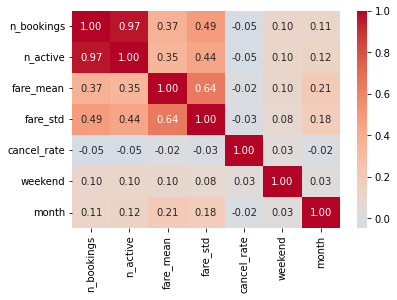

In [104]:

sns.heatmap(X.corr()
, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [105]:
X = flight_level_new.drop(columns=['inv_leg_id', 'route_group', 'model','dep_date','n_active'])


In [106]:
X

,n_bookings,fare_mean,fare_std,cancel_rate,weekend,month
0,136,72.638971,42.523325,-0.298077,1,6
1,126,45.592302,13.330105,-0.194175,1,6
2,139,85.529856,45.590604,-0.225225,1,6
3,140,34.278929,33.215854,-0.207207,1,6
4,136,138.982132,45.920614,-0.168142,1,6
...,...,...,...,...,...,...
2396,132,40.092424,16.924310,-0.257143,0,8
2397,138,65.687101,56.203983,-0.212389,0,8
2398,128,46.596562,24.304592,-0.255102,0,8
2399,104,35.981250,21.695753,-0.223529,0,8


In [110]:

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
}

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
}


results = []
for name, pipeline in models.items():
    cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)
    results.append({
        'model': name,
        'accuracy': cv_results['test_accuracy'].mean(),
        'accuracy_std': cv_results['test_accuracy'].std(),
        'precision_macro': cv_results['test_precision_macro'].mean(),
        'recall_macro': cv_results['test_recall_macro'].mean(),
        'f1_macro': cv_results['test_f1_macro'].mean(),
    })

results_df = pd.DataFrame(results).set_index('model')
print(results_df.round(3))

                     accuracy  accuracy_std  precision_macro  recall_macro  \
model                                                                        
Logistic Regression     0.931         0.012            0.928         0.927   
Random Forest           0.943         0.020            0.941         0.941   
KNN                     0.926         0.022            0.928         0.917   

                     f1_macro  
model                          
Logistic Regression     0.927  
Random Forest           0.940  
KNN                     0.921  


In [125]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_pipeline = models['Logistic Regression']
lr_pipeline.fit(X_train, y_train)

lr = lr_pipeline.named_steps['clf']


In [112]:
coef_series = pd.Series(lr.coef_[0], index=X.columns).sort_values()
print(coef_series)

fare_mean     -7.233515
cancel_rate   -0.170178
n_bookings     0.262726
month          0.477222
weekend        0.723920
fare_std       2.613594
dtype: float64


In [113]:
df_new

,inv_leg_id,route_group,departure_date,model,passenger_id,fare_eur,is_active,booking_ts
0,1135416914,UKP,2025-06-01,B,273640483620,59.80,True,2025-05-11 12:58:31.637
1,1135416914,UKP,2025-06-01,B,258113633041,67.63,True,2024-10-25 13:48:21.847
2,1135416914,UKP,2025-06-01,B,272884203663,54.31,True,2025-05-02 16:05:19.973
3,1135416914,UKP,2025-06-01,B,270912249902,47.37,True,2025-04-08 16:47:18.887
4,1135416914,UKP,2025-06-01,B,270822533080,54.31,True,2025-04-07 18:20:28.130
...,...,...,...,...,...,...,...,...
311042,1220617150,UKP,2025-08-28,B,279231218454,41.59,True,2025-07-21 16:58:45.140
311043,1220617150,UKP,2025-08-28,B,281730526380,228.82,True,2025-08-27 22:01:23.763
311044,1220617150,UKP,2025-08-28,B,281159443240,37.84,True,2025-08-19 17:57:11.063
311045,1220617150,UKP,2025-08-28,B,281750938060,251.94,True,2025-08-28 09:59:01.970


In [114]:
df_new.groupby("route_group")["fare_eur"].mean()

route_group
CANARY    140.291943
UKP        56.643088
Name: fare_eur, dtype: float64

In [115]:
df_new.groupby('route_group')['inv_leg_id'].nunique()

route_group
CANARY     920
UKP       1481
Name: inv_leg_id, dtype: int64

In [116]:
 df_new.groupby('route_group')['passenger_id'].count() / df_new.groupby('route_group')['inv_leg_id'].nunique()

route_group
CANARY    134.663043
UKP       126.372046
dtype: float64

In [117]:
rf_pipeline = models['Random Forest']
rf_pipeline.fit(X_train, y_train)

rf_importances = pd.Series(
    rf_pipeline.named_steps['clf'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importances)

fare_mean      0.654929
fare_std       0.152385
n_bookings     0.097493
cancel_rate    0.060216
month          0.022724
weekend        0.012253
dtype: float64


In [118]:
from sklearn.metrics import cohen_kappa_score

y_pred_rf = rf_pipeline.predict(X_test)
y_pred_lr = lr_pipeline.predict(X_test)

agreement = (y_pred_rf == y_pred_lr).mean()
kappa = cohen_kappa_score(y_pred_rf, y_pred_lr)

print(f"Prediction agreement (RF vs LR): {agreement:.3f}")
print(f"Cohen's kappa: {kappa:.3f}")

Prediction agreement (RF vs LR): 0.958
Cohen's kappa: 0.911


In [119]:
# Choose LR for interpretability, RF for better predictions

In [126]:
# Build single pipeline to be saved

if save_prediction_model:
    pipeline_prediction =models['Logistic Regression']
    
    pipeline_prediction.fit(X_train, y_train)
    
    output_file = Path(output_path) / "prediction_pipeline.pkl"
    
    with open(output_file, "wb") as f:
        pickle.dump(pipeline_prediction, f)
    
    print(f"Pipeline saved to: {output_file}")

Pipeline saved to: C:\Users\Fabrizio\Downloads\ds-test-main\ds-test-main\output\prediction_pipeline.pkl


In [ ]:
# To explain the model to business, I chose LR since it performs similarly to RF.
# Noticing that the main variable driving he prediction is the revenue per flight, it is important to take that into account in the model
# production: future high fare flights could be classified CANARY only because of that